### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [195]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
from pycbc.psd import from_numpy_arrays
import random


Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

[-6.83133358e-21 -6.52052350e-21 -6.78056106e-21 ... -8.58657783e-22
 -6.02284885e-22 -7.59861259e-22]
number of time samples: 40961
seperation of samples: 0.000244140625
Delta f: 0.05
Delta t 0.000244140625


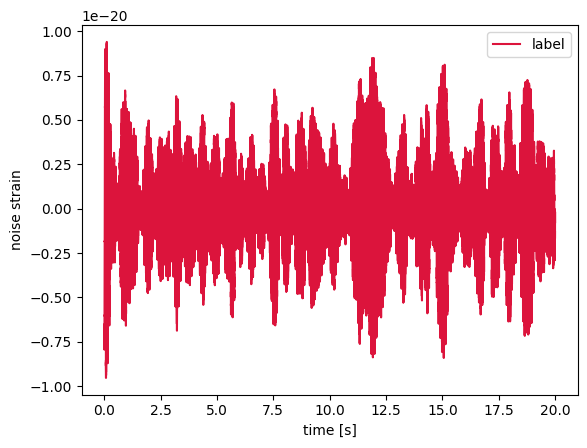

In [196]:
psd_data = np.loadtxt("aligo_O4high.txt")
#-----load values onto array-----#
freqs = psd_data[:,0] #frequency values onto 1st column
scale_d = psd_data[:,1]
psd_var = scale_d**2 #necessary scale down for later ex.

#-----variable construction-----#
delta_t = 1/4096 #sampling frequency (Hz)
duration = 20 #seconds
delta_f = 1/duration #
length = int(duration/delta_t)

psd_len = int(duration/delta_t)//2 + 1 #filtering psd data due to symmetry 
#(positive freq. =- neg. freq.)
#^ filtered until nyquist frequency

f_min = 12 #code fix to find the minimum frequency band, otherwise code breaks

psd = from_numpy_arrays(freqs, psd_var, 
                        length=psd_len, 
                        delta_f=delta_f, 
                        low_freq_cutoff=f_min)
noise = pycbc.noise.gaussian.noise_from_psd(delta_t=delta_t,
                                            psd=psd, 
                                            seed = None, 
                                            length=int(duration/delta_t))
#-----code check-----#
print(noise)
print("number of time samples:", psd_len)
print("seperation of samples:", noise.delta_t)
print("Delta f:", delta_f)
print("Delta t", delta_t)

#-----Visualisation of noise-----#
plt.plot(noise.sample_times , noise, label="label", color="crimson")
plt.ylabel("noise strain")
plt.xlabel("time [s]")
plt.legend()
plt.show()

As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise. 

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

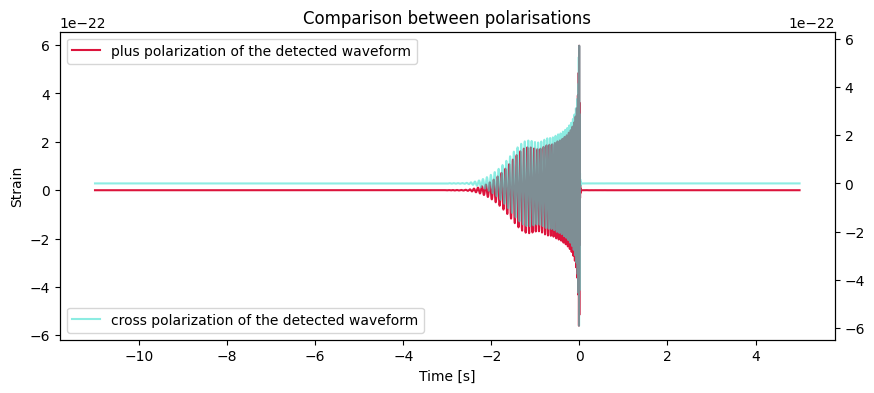

In [197]:
#-----initialised waveform with requested parameters-----#
hplus, hcross = pycbc.waveform.waveform.get_td_waveform(approximant="IMRPhenomD", 
                                                 mass1=50, mass2=50, 
                                                 distance=2000, 
                                                 f_lower=f_min, 
                                                 delta_t= delta_t)

#-----plotting both polarizations for clarity-----#
fig, a1 = plt.subplots(figsize=(10,4))
plt.plot(hplus.sample_times, hplus, label="plus polarization of the detected waveform", 
           color="crimson")
a1.set_xlabel("Time [s]")
a1.set_ylabel("Strain")
a1.legend(loc="upper left")
a2 = a1.twinx()
plt.plot(hcross.sample_times, hcross, label="cross polarization of the detected waveform",
           color="turquoise", alpha=0.6)
a2.legend(loc="lower left")
plt.title("Comparison between polarisations")
plt.show()


In [198]:
detector = Detector("L1") #chosen detector 

#-----random projection coordinates-----#
ra = np.random.uniform(0, 2*np.pi)
dec = np.random.uniform(-2*np.pi, 2*np.pi)
polarization = np.random.uniform(0, 2*np.pi)

#projecting the wave at a random location
wave = detector.project_wave(hplus, hcross, ra, dec, polarization)


**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD. 

_Bonus:_ Can you also plot the GW signal? 


After 4s the PSD has 16384 data points.
Scaling down the initial noise data was necessary to see the injected wave, as it was almost 10 orders of magnitude smaller than the noise!


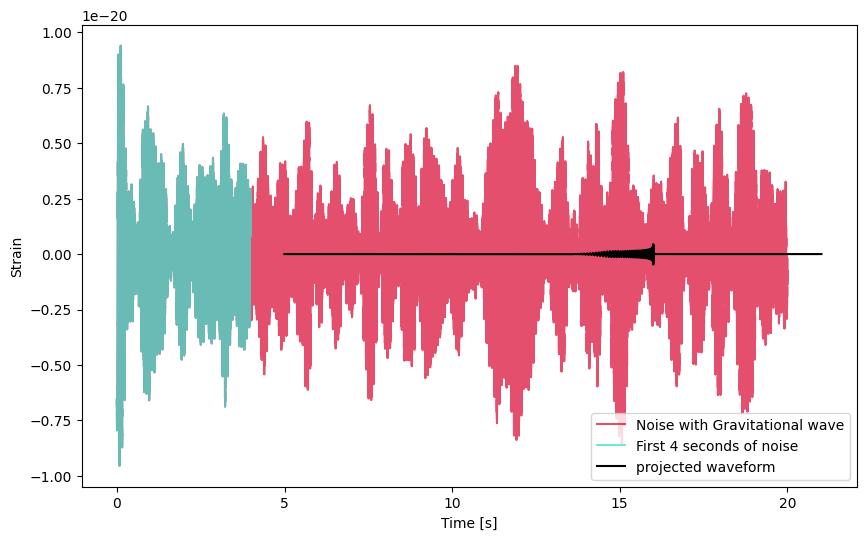

In [199]:
#assigning start times
noise.start_time = 0
wave.start_time = noise.start_time + 5 

start_t = int(5/delta_t)

psd_4s = noise[:int(4/delta_t)]

print(f"After 4s the PSD has",len(psd_4s), "data points.")

data = noise.copy() #copying noise data onto a new variable to then add the GW

#-----Injecting GW data into noise-----#
data[int(start_t) : int(start_t) + len(wave[:len(data) - start_t])] += wave[:len(data) - start_t]

#-----Noise + GW-----#
fig = plt.figure(figsize=[10,6])
plt.plot(data.sample_times, data, label="Noise with Gravitational wave", alpha=0.75, color ='crimson')
plt.plot(psd_4s.sample_times, psd_4s, label="First 4 seconds of noise", alpha=0.75, color="turquoise")
plt.plot(wave.sample_times, wave, label="projected waveform", color="black")
plt.ylabel("Strain")
plt.xlabel("Time [s]")
plt.legend()

print("Scaling down the initial noise data was necessary to see the injected wave, as it was almost 10 orders of magnitude smaller than the noise!")

The wave is barely noticeable within the noise, checking if its properly projected..

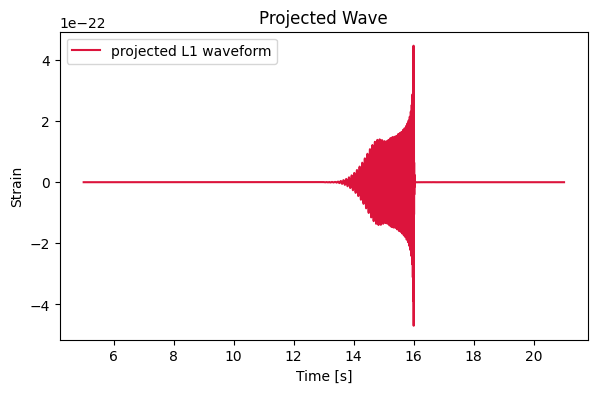

In [200]:

#-----Visualising the waveform-----#
fig = plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(wave.sample_times, wave, label="projected L1 waveform", color="crimson")
plt.title("Projected Wave")
plt.ylabel("Strain")
plt.xlabel("Time [s]")
plt.legend()
plt.show()

**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


In [201]:
s_rate = 4096
welch=pycbc.psd.estimate.welch(psd_4s, seg_len=s_rate*4, seg_stride=s_rate*2, window='hann', avg_method='median', num_segments=None, require_exact_data_fit=False)

print(len(welch))
print("Estimated PSD's Delta f:", welch.delta_f)
print("The Delta f of our data:", data.delta_f)

8193
Estimated PSD's Delta f: 0.25
The Delta f of our data: 0.05


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency. 

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

In [202]:
#-----Interpolating psd with s_rate-----#
interp_psdw = pycbc.psd.estimate.interpolate(welch, delta_f, length=None)
print(len(interp_psdw)) #Notice welch went from 8193 to 40961 entries equal to original data now

truncuate_psdw = pycbc.psd.estimate.inverse_spectrum_truncation(interp_psdw, max_filter_len=4*s_rate, low_frequency_cutoff=12, trunc_method=None)

print(f"our data delta f:", data.delta_f, "truanced welch delta f:", truncuate_psdw.delta_f)


40961
our data delta f: 0.05 truanced welch delta f: 0.05


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

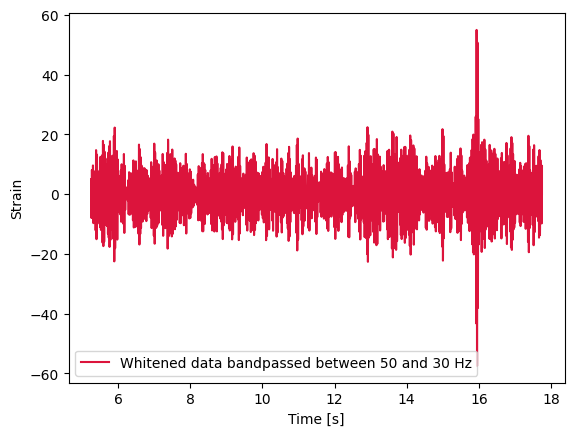

In [203]:
freq_series = data.to_frequencyseries() #converting data into a frequency series to satisfy equation

whiten_data = freq_series/np.sqrt(truncuate_psdw) #this achieves the equation

whiten_data=whiten_data.to_timeseries() #allows to work back with time series methods

whiten_data = whiten_data[int(5/whiten_data.delta_t): int(18/whiten_data.delta_t)] 
#^ cuts borders to the chosen ones (from 5 to 15 (for myself))

#-----Bandpassing data-----#
whiten_data = whiten_data.lowpass_fir(50,512).highpass_fir(30,512)

#-----Plotting-----#
plt.plot(whiten_data.sample_times, whiten_data, label="Whitened data bandpassed between 50 and 30 Hz", color="crimson")
plt.ylabel("Strain")
plt.xlabel("Time [s]")
plt.legend()
plt.show()


The GW became more clear at lower bandpass frequencies

So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$, 

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform. 

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df. 
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

time length of GW: 65603
resized time length of GW: 81920


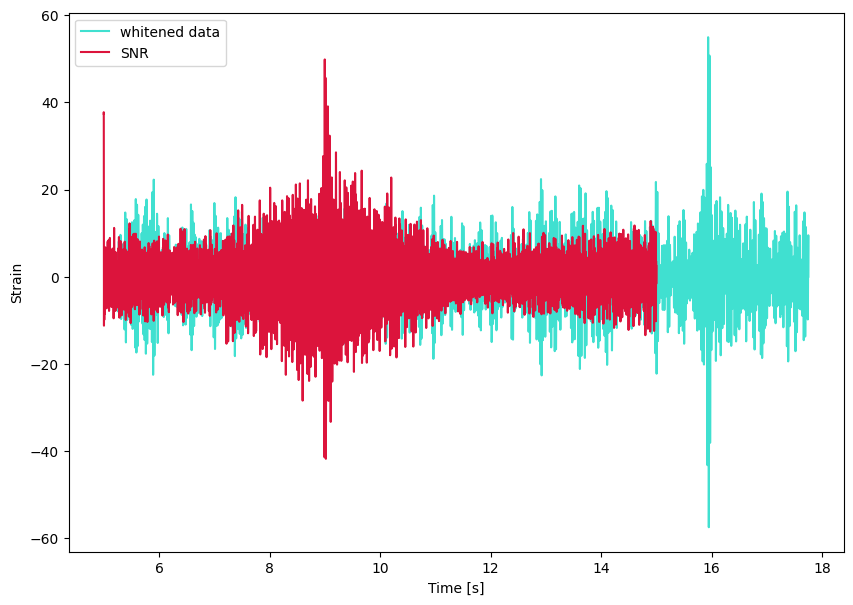

max |SNR| = 52.90431532974201
peak time = 8.997802734375 s


In [204]:
template = wave.copy()
print(f"time length of GW:", len(template))

template.resize(len(data)) #make the GW match the size of the data

print(f"resized time length of GW:", len(template))

template.start_time = data.start_time #make sure both arrays start at the same time for clarity

#-----Filtering of the coloured data through the template-----#
SNR = pycbc.filter.matchedfilter.matched_filter(template = template, 
                                                data = data, 
                                                psd=truncuate_psdw)
SNR = SNR.crop(5,5)

#-----Plotting both graphs-----#
fig = plt.subplots(figsize=[10,7])
plt.plot(whiten_data.sample_times, whiten_data, label = "whitened data", color="turquoise")
plt.ylabel("Strain")
plt.legend()
plt.xlabel("Time [s]")
plt.plot(SNR.sample_times, SNR, label = "SNR", color = "crimson")
plt.legend()
plt.show()


#-----Checking for maximum SNR values-----#
abs_SNR = abs(SNR)
i_peak = np.argmax(abs_SNR)

max_abs_SNR = float(abs_SNR[i_peak])
peak_time = float(SNR.sample_times[i_peak])

print("max |SNR| =", max_abs_SNR)
print("peak time =", peak_time, "s")

Since the maximum absolute value of SNR is above 5, it is a trigger for further analysis, as it implies a possible GW event.

Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting. 

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer. 